# Laboratorio 4 — Cuaderno 10: validación espacial y temporal

**Ejercicio 6 de la Parte 2**, más la validación temporal que pide la rúbrica de
evaluación.

El cuaderno 9 terminó con una advertencia: la división 70/30 reparte píxeles al azar, y
píxeles vecinos separados por 20 metros son casi el mismo dato. Es prácticamente seguro
que para cada píxel del conjunto de prueba haya uno contiguo en el de entrenamiento, con
la misma reflectancia y la misma etiqueta. El modelo no tuvo que generalizar a ninguna
zona nueva; le bastó recordar.

Este cuaderno mide cuánto de aquel resultado era memoria. Se compara la misma receta bajo
tres particiones distintas:

| Partición | Qué se le oculta al modelo | Qué pregunta responde |
|---|---|---|
| Aleatoria | Píxeles sueltos | ¿Puede rellenar huecos en una zona que ya conoce? |
| **Espacial** | Bloques de 1 km × 1 km completos | ¿Puede predecir en una zona del lago donde nunca vio nada? |
| **Temporal** | Fechas completas | ¿Puede predecir en una fecha que nunca vio? |

Las dos últimas son las que corresponden al uso real del modelo.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

from src import config, datos as dts, ml

SEMILLA = 42

datos = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
datos[ml.RESPUESTA] = ml.variable_respuesta(datos)
datos = ml.caracteristicas(datos)

X = datos[ml.PREDICTORAS]
y = datos[ml.RESPUESTA]

print(f"{len(datos):,} observaciones, {int(y.sum()):,} positivos ({100*y.mean():.2f} %)")

COLOR_MODELO = {"Regresión Logística": "#2f6fb0", "Random Forest": "#2e8b57", "XGBoost": "#d95f02"}

3,759,121 observaciones, 44,349 positivos (1.18 %)


## 6.1 Sistema de referencia y tamaño de bloque

El inciso pide reproyectar a **WGS 84 / UTM zona 15N (EPSG:32615)** antes de construir la
cuadrícula. Conviene verificarlo en vez de asumirlo:

In [2]:
for lago in ["Atitlan", "Amatitlan"]:
    _, meta = dts.leer_cubo(lago, config.FECHAS[lago][0])
    print(f"{lago:<11} CRS del raster: {meta['crs']}   resolución: "
          f"{meta['transform'].a:.0f} x {abs(meta['transform'].e):.0f} m")

print(f"\nRango de las coordenadas en el conjunto de datos:")
print(f"  x: {datos['x'].min():,.0f} a {datos['x'].max():,.0f} m")
print(f"  y: {datos['y'].min():,.0f} a {datos['y'].max():,.0f} m")

Atitlan     CRS del raster: EPSG:32615   resolución: 20 x 20 m
Amatitlan   CRS del raster: EPSG:32615   resolución: 20 x 20 m

Rango de las coordenadas en el conjunto de datos:
  x: 680,510 a 768,170 m
  y: 1,594,630 a 1,631,570 m


Los rasters ya están en EPSG:32615, así que **no hace falta reproyectar nada**. No es
casualidad: se le pidió esa proyección a openEO en el momento de la descarga, en la Parte
I, precisamente porque las coordenadas en metros son las que permiten construir una
cuadrícula métrica. Las coordenadas `x` e `y` del conjunto de datos están en metros, y la
cuadrícula se arma dividiendo entre el lado del bloque.

### ¿Alcanzan los bloques de 1 km?

El enunciado pide evaluar si ese tamaño produce suficientes bloques con observaciones
válidas antes de usarlo. Se comparan tres tamaños:

In [3]:
comparacion_lados = pd.concat(
    [ml.resumen_bloques(datos, lado) for lado in (500, 1000, 2000)], ignore_index=True
)
print(comparacion_lados.to_string(index=False))

     lago  lado_m  bloques  obs_min  obs_mediana  obs_max  bloques_con_positivos
Amatitlan     500      132        1         2452     6875                    103
  Atitlan     500      693        1         6875     6875                     95
Amatitlan    1000       58        1         1827    27500                     37
  Atitlan    1000      232        1        15820    27500                     65
Amatitlan    2000       25        1         3841    90997                     16
  Atitlan    2000       83        1        14115   110000                     38


Con **1 km × 1 km** salen 232 bloques en Atitlán y 58 en Amatitlán, de los cuales 65 y 37
respectivamente contienen al menos un píxel positivo. Para una validación cruzada de 5
particiones eso significa unos 46 bloques por partición en Atitlán y 12 en Amatitlán, con
positivos en todas. **Es suficiente y se conserva el tamaño que sugiere el enunciado.**

Los otros dos tamaños se descartan con argumentos concretos, no por descarte automático:

- **500 m** daría más bloques (693 y 132), pero medio kilómetro es del orden del tamaño de
  una mancha de floración. Bloques así de pequeños dejarían la misma mancha repartida
  entre entrenamiento y prueba, que es exactamente la fuga espacial que se quiere evitar.
- **2 km** deja 25 bloques en Amatitlán, con solo 16 conteniendo positivos. Repartidos en
  5 particiones son 3 bloques con positivos por partición: la estimación tendría tanta
  varianza que no serviría para comparar nada.

Un detalle de la tabla: el mínimo de observaciones por bloque es 1 en todos los tamaños.
Son bloques de borde que apenas rozan el espejo de agua. No se eliminan —no hacen daño,
porque el agrupamiento solo garantiza que sus píxeles no se repartan— pero explican por
qué la mediana es mucho más informativa que el mínimo.

## 6.2 Asignación de observaciones a bloques y mapa de la cuadrícula

In [4]:
LADO = 1000.0
datos["bloque"] = ml.asignar_bloques(datos, LADO)

print(f"Bloques de {LADO:.0f} m: {datos['bloque'].nunique()} en total")
print(datos.groupby("lago")["bloque"].nunique().to_string())

print("\nObservaciones por bloque (todas las fechas juntas):")
print(datos.groupby(["lago", "bloque"]).size().groupby("lago").describe()[
    ["count", "mean", "min", "50%", "max"]].round(0).to_string())

Bloques de 1000 m: 290 en total
lago
Amatitlan     58
Atitlan      232

Observaciones por bloque (todas las fechas juntas):


           count     mean  min      50%      max
lago                                            
Amatitlan   58.0   6910.0  1.0   1827.0  27500.0
Atitlan    232.0  14476.0  1.0  15820.0  27500.0


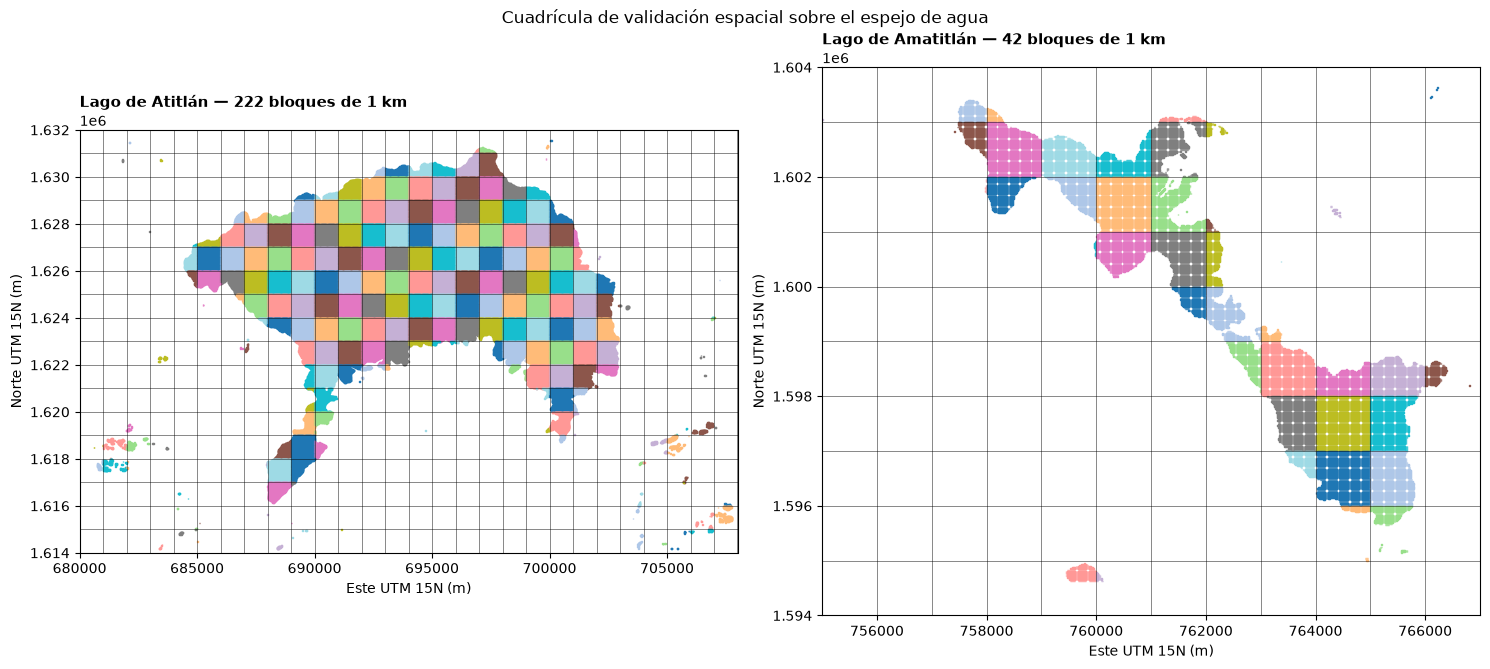

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 6.4))

for eje, lago in zip(ejes, ["Atitlan", "Amatitlan"]):
    sub = datos[(datos["lago"] == lago) & (datos["fecha"] == datos.loc[datos["lago"] == lago, "fecha"].min())]
    codigos = pd.factorize(sub["bloque"])[0]

    eje.scatter(sub["x"], sub["y"], c=codigos % 12, cmap="tab20", s=0.35, marker="s")

    x0 = np.floor(sub["x"].min() / LADO) * LADO
    x1 = np.ceil(sub["x"].max() / LADO) * LADO
    y0 = np.floor(sub["y"].min() / LADO) * LADO
    y1 = np.ceil(sub["y"].max() / LADO) * LADO
    for xv in np.arange(x0, x1 + LADO, LADO):
        eje.axvline(xv, color="black", linewidth=0.6, alpha=0.55)
    for yv in np.arange(y0, y1 + LADO, LADO):
        eje.axhline(yv, color="black", linewidth=0.6, alpha=0.55)

    n_bloques = sub["bloque"].nunique()
    eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {n_bloques} bloques de 1 km",
                  loc="left", fontsize=11, fontweight="bold")
    eje.set_xlabel("Este UTM 15N (m)")
    eje.set_ylabel("Norte UTM 15N (m)")
    eje.set_aspect("equal")
    eje.set_xlim(x0, x1)
    eje.set_ylim(y0, y1)

fig.suptitle("Cuadrícula de validación espacial sobre el espejo de agua", y=1.0)
fig.tight_layout()
plt.show()

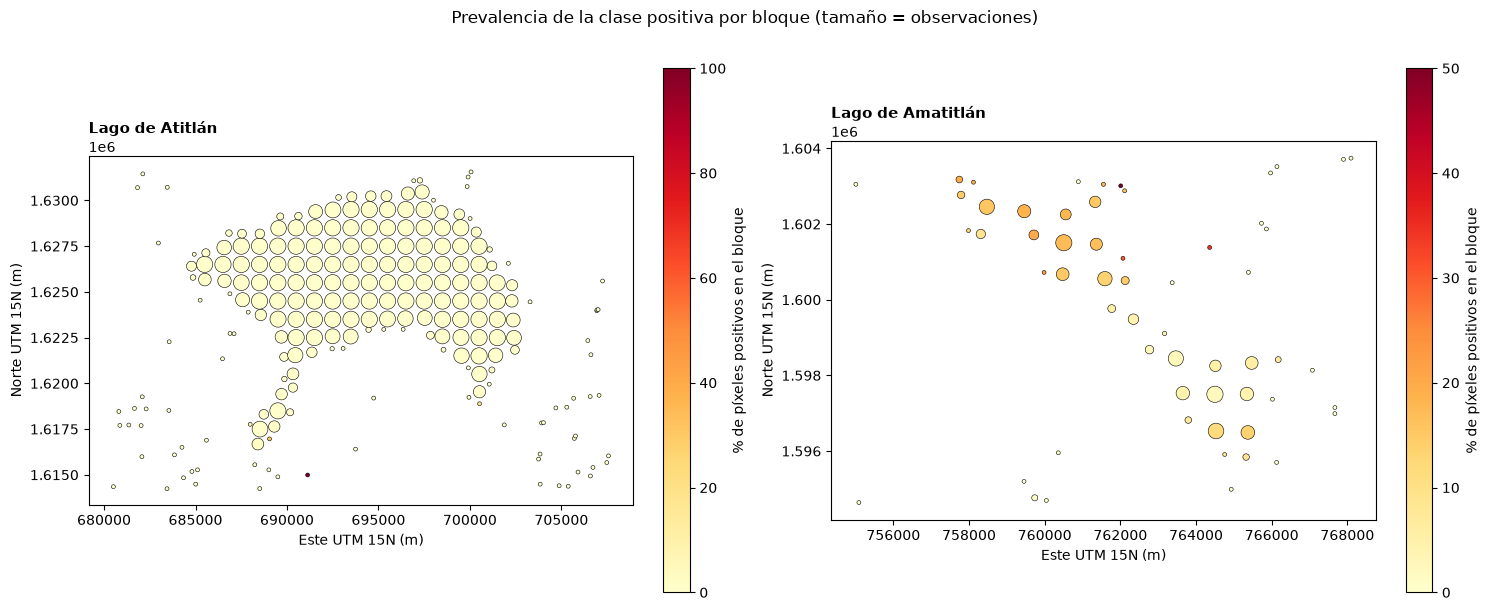

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 6.0))

for eje, lago in zip(ejes, ["Atitlan", "Amatitlan"]):
    sub = datos[datos["lago"] == lago]
    por_bloque = sub.groupby("bloque").agg(
        x=("x", "mean"), y=("y", "mean"), positivos=(ml.RESPUESTA, "mean"), n=("x", "size")
    )
    dibujo = eje.scatter(por_bloque["x"], por_bloque["y"], c=100 * por_bloque["positivos"],
                         s=np.clip(por_bloque["n"] / 200, 8, 260), cmap="YlOrRd",
                         edgecolor="black", linewidth=0.4)
    fig.colorbar(dibujo, ax=eje, label="% de píxeles positivos en el bloque", fraction=0.046)
    eje.set_title(f"{config.NOMBRE_LARGO[lago]}", loc="left", fontsize=11, fontweight="bold")
    eje.set_xlabel("Este UTM 15N (m)")
    eje.set_ylabel("Norte UTM 15N (m)")
    eje.set_aspect("equal")

fig.suptitle("Prevalencia de la clase positiva por bloque (tamaño = observaciones)", y=1.01)
fig.tight_layout()
plt.show()

El segundo mapa explica por adelantado por qué la validación espacial va a costar
desempeño. La clase positiva no está esparcida al azar sobre el lago: en Amatitlán se
concentra en la mitad oriental, que es donde la Parte I localizó los focos persistentes,
entre 3 y 6 km de San Miguel Petapa y frente a la descarga del río Villalobos. Hay bloques
con más del 30 % de píxeles positivos y bloques contiguos casi limpios.

Cuando una partición aleatoria parte esos bloques, el modelo ve la mitad de cada foco
durante el entrenamiento. Cuando la partición es por bloques, el foco entero desaparece o
entero se queda, y predecirlo exige haber aprendido algo que se transfiera.

## 6.3 y 6.4 Las tres estrategias de validación

Se usa `StratifiedGroupKFold` en lugar de `GroupKFold` a secas. Respeta los grupos igual
—ningún bloque se reparte entre entrenamiento y prueba— pero además equilibra la
proporción de positivos entre particiones. Con una clase al 1.18 % y focos concentrados en
unos pocos bloques, `GroupKFold` sin estratificar puede producir particiones sin apenas
positivos, y entonces la métrica mide el sorteo en vez del modelo.

Dentro de cada partición se aplica **exactamente el mismo protocolo del cuaderno 9**: se
aparta un 30 % del entrenamiento como validación interna con su prevalencia intacta, se
submuestrea el resto a 1:1, se ajusta el modelo con los hiperparámetros ya elegidos, se
escoge el umbral maximizando F2 sobre la validación interna y se evalúa sobre la partición
retenida. Los hiperparámetros no se vuelven a buscar, para que la única diferencia entre
las tres estrategias sea cómo se repartieron los datos.

In [7]:
def correr_validacion(divisiones, etiqueta):
    salida = {}
    for nombre in ml.HIPERPARAMETROS:
        folds = []
        t0 = time.time()
        for k, (i_ent, i_pru) in enumerate(divisiones):
            folds.append(
                ml.entrenar_y_evaluar(
                    nombre, X.iloc[i_ent], y.iloc[i_ent], X.iloc[i_pru], y.iloc[i_pru],
                    semilla=SEMILLA + k,
                )
            )
        salida[nombre] = {"folds": folds, "resumen": ml.promedio_folds(folds)}
        r = salida[nombre]["resumen"]
        print(f"  {nombre:<22} F2 = {r['F2']:.4f} ± {r['F2_sd']:.4f}   "
              f"Recall = {r['Recall']:.4f}   PR-AUC = {r['PR-AUC']:.4f}   "
              f"({time.time()-t0:.0f} s)")
    return salida


particiones = {}

print("1. Validación ALEATORIA (StratifiedKFold, 5 particiones)")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
particiones["Aleatoria"] = correr_validacion(list(skf.split(X, y)), "aleatoria")

print("\n2. Validación ESPACIAL (bloques de 1 km, StratifiedGroupKFold, 5 particiones)")
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
particiones["Espacial"] = correr_validacion(
    list(sgkf.split(X, y, groups=datos["bloque"])), "espacial"
)

print("\n3. Validación TEMPORAL (por fecha, StratifiedGroupKFold, 5 particiones)")
particiones["Temporal"] = correr_validacion(
    list(sgkf.split(X, y, groups=datos["fecha"].astype(str))), "temporal"
)

1. Validación ALEATORIA (StratifiedKFold, 5 particiones)


  Regresión Logística    F2 = 0.9229 ± 0.0009   Recall = 0.9665   PR-AUC = 0.9188   (57 s)


  Random Forest          F2 = 0.9311 ± 0.0006   Recall = 0.9674   PR-AUC = 0.9710   (37 s)


  XGBoost                F2 = 0.9439 ± 0.0020   Recall = 0.9743   PR-AUC = 0.9793   (27 s)

2. Validación ESPACIAL (bloques de 1 km, StratifiedGroupKFold, 5 particiones)


  Regresión Logística    F2 = 0.9211 ± 0.0122   Recall = 0.9662   PR-AUC = 0.9171   (50 s)


  Random Forest          F2 = 0.9186 ± 0.0135   Recall = 0.9504   PR-AUC = 0.9620   (36 s)


  XGBoost                F2 = 0.9355 ± 0.0102   Recall = 0.9689   PR-AUC = 0.9728   (27 s)

3. Validación TEMPORAL (por fecha, StratifiedGroupKFold, 5 particiones)


  Regresión Logística    F2 = 0.8372 ± 0.0720   Recall = 0.9021   PR-AUC = 0.8455   (49 s)


  Random Forest          F2 = 0.6144 ± 0.1692   Recall = 0.6101   PR-AUC = 0.8464   (37 s)


  XGBoost                F2 = 0.8176 ± 0.0838   Recall = 0.8342   PR-AUC = 0.9009   (27 s)


In [8]:
print("Fechas retenidas en cada partición temporal:\n")
for k, (_, i_pru) in enumerate(sgkf.split(X, y, groups=datos["fecha"].astype(str))):
    fechas = sorted(datos.iloc[i_pru]["fecha"].dt.strftime("%Y-%m-%d").unique())
    pos = int(y.iloc[i_pru].sum())
    print(f"  partición {k}: {len(fechas)} fechas, {pos:>6,} positivos — {', '.join(fechas)}")

Fechas retenidas en cada partición temporal:



  partición 0: 3 fechas, 21,865 positivos — 2026-04-13, 2026-06-19, 2026-07-22


  partición 1: 3 fechas, 12,512 positivos — 2025-05-13, 2026-02-02, 2026-04-28


  partición 2: 5 fechas,  3,757 positivos — 2025-01-18, 2025-01-28, 2025-04-13, 2025-11-24, 2026-03-29


  partición 3: 5 fechas,  2,987 positivos — 2025-04-15, 2025-12-29, 2026-01-08, 2026-02-07, 2026-03-24


  partición 4: 4 fechas,  3,228 positivos — 2025-04-28, 2025-07-17, 2025-11-21, 2026-02-12


## 6.5 Comparación de las tres estrategias

In [9]:
filas = []
for estrategia, contenido in particiones.items():
    for nombre, res in contenido.items():
        r = res["resumen"]
        filas.append({
            "estrategia": estrategia, "modelo": nombre,
            "Recall": r["Recall"], "Precision": r["Precision"],
            "F1": r["F1"], "F2": r["F2"], "F2_sd": r["F2_sd"],
            "PR-AUC": r["PR-AUC"], "ROC-AUC": r["ROC-AUC"],
        })

resumen = pd.DataFrame(filas).round(4)
print(resumen.to_string(index=False))

estrategia              modelo  Recall  Precision     F1     F2  F2_sd  PR-AUC  ROC-AUC
 Aleatoria Regresión Logística  0.9665     0.7820 0.8644 0.9229 0.0009  0.9188   0.9991
 Aleatoria       Random Forest  0.9674     0.8098 0.8816 0.9311 0.0006  0.9710   0.9996
 Aleatoria             XGBoost  0.9743     0.8392 0.9017 0.9439 0.0020  0.9793   0.9997
  Espacial Regresión Logística  0.9662     0.7768 0.8610 0.9211 0.0122  0.9171   0.9991
  Espacial       Random Forest  0.9504     0.8149 0.8758 0.9186 0.0135  0.9620   0.9995
  Espacial             XGBoost  0.9689     0.8240 0.8899 0.9355 0.0102  0.9728   0.9996
  Temporal Regresión Logística  0.9021     0.6698 0.7617 0.8372 0.0720  0.8455   0.9981
  Temporal       Random Forest  0.6101     0.7910 0.6421 0.6144 0.1692  0.8464   0.9981
  Temporal             XGBoost  0.8342     0.7846 0.7996 0.8176 0.0838  0.9009   0.9985


In [10]:
pivote = resumen.pivot(index="modelo", columns="estrategia", values="F2")[
    ["Aleatoria", "Espacial", "Temporal"]]
pivote["Δ espacial"] = (pivote["Espacial"] - pivote["Aleatoria"]).round(4)
pivote["Δ temporal"] = (pivote["Temporal"] - pivote["Aleatoria"]).round(4)
print("F2 por estrategia y caída respecto a la validación aleatoria\n")
print(pivote.round(4).to_string())

print("\nMismo cálculo sobre PR-AUC\n")
pivote_pr = resumen.pivot(index="modelo", columns="estrategia", values="PR-AUC")[
    ["Aleatoria", "Espacial", "Temporal"]]
pivote_pr["Δ espacial"] = (pivote_pr["Espacial"] - pivote_pr["Aleatoria"]).round(4)
pivote_pr["Δ temporal"] = (pivote_pr["Temporal"] - pivote_pr["Aleatoria"]).round(4)
print(pivote_pr.round(4).to_string())

F2 por estrategia y caída respecto a la validación aleatoria

estrategia           Aleatoria  Espacial  Temporal  Δ espacial  Δ temporal
modelo                                                                    
Random Forest           0.9311    0.9186    0.6144     -0.0125     -0.3167
Regresión Logística     0.9229    0.9211    0.8372     -0.0018     -0.0857
XGBoost                 0.9439    0.9355    0.8176     -0.0084     -0.1263

Mismo cálculo sobre PR-AUC

estrategia           Aleatoria  Espacial  Temporal  Δ espacial  Δ temporal
modelo                                                                    
Random Forest           0.9710    0.9620    0.8464     -0.0090     -0.1246
Regresión Logística     0.9188    0.9171    0.8455     -0.0017     -0.0733
XGBoost                 0.9793    0.9728    0.9009     -0.0065     -0.0784


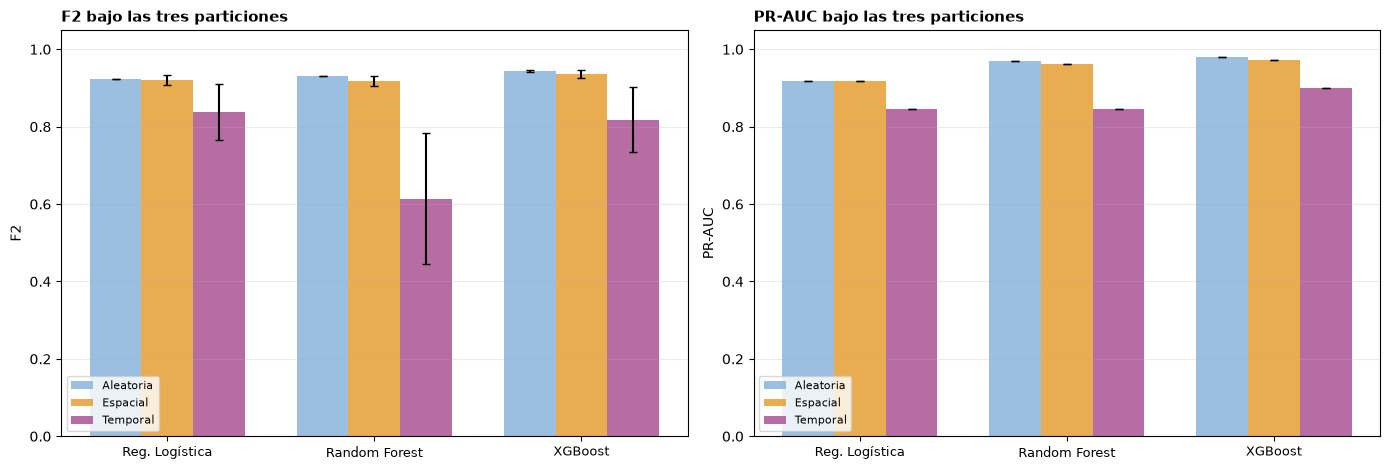

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.8))

for eje, metrica in zip(ejes, ["F2", "PR-AUC"]):
    ancho = 0.25
    for k, estrategia in enumerate(["Aleatoria", "Espacial", "Temporal"]):
        sub = resumen[resumen["estrategia"] == estrategia].set_index("modelo")
        modelos_orden = list(ml.HIPERPARAMETROS)
        valores = [sub.loc[m, metrica] for m in modelos_orden]
        errores = [sub.loc[m, "F2_sd"] if metrica == "F2" else 0 for m in modelos_orden]
        pos = np.arange(len(modelos_orden)) + (k - 1) * ancho
        eje.bar(pos, valores, ancho, yerr=errores, capsize=3,
                label=estrategia, alpha=0.9,
                color=["#8fb8de", "#e8a33d", "#b05c9a"][k])
    eje.set_xticks(np.arange(3), ["Reg. Logística", "Random Forest", "XGBoost"], fontsize=9)
    eje.set_ylabel(metrica)
    eje.set_ylim(0, 1.05)
    eje.set_title(f"{metrica} bajo las tres particiones", loc="left",
                  fontsize=11, fontweight="bold")
    eje.legend(fontsize=8)
    eje.grid(alpha=0.25, axis="y")

fig.tight_layout()
plt.show()

In [12]:
print("Dispersión entre particiones — F2 de cada fold (XGBoost)\n")
for estrategia in ["Aleatoria", "Espacial", "Temporal"]:
    valores = [f["F2"] for f in particiones[estrategia]["XGBoost"]["folds"] if f.get("valido")]
    print(f"  {estrategia:<11}" + "  ".join(f"{v:.4f}" for v in valores)
          + f"    rango = {max(valores)-min(valores):.4f}")

Dispersión entre particiones — F2 de cada fold (XGBoost)

  Aleatoria  0.9437  0.9444  0.9406  0.9441  0.9467    rango = 0.0061
  Espacial   0.9430  0.9413  0.9160  0.9424  0.9346    rango = 0.0270
  Temporal   0.6942  0.9522  0.7800  0.8316  0.8300    rango = 0.2580


## 6.6 Interpretación

### Cuánto baja el desempeño, y dónde

Las tres particiones se ordenan igual para los tres modelos —aleatoria > espacial >
temporal— pero las dos caídas son de naturaleza completamente distinta.

| Modelo | F2 aleatoria | F2 espacial | Δ | F2 temporal | Δ |
|---|---|---|---|---|---|
| Regresión Logística | 0.9229 | 0.9211 | −0.0018 | 0.8372 | −0.0857 |
| Random Forest | 0.9311 | 0.9186 | −0.0125 | 0.6144 | **−0.3167** |
| XGBoost | 0.9439 | 0.9355 | −0.0084 | 0.8176 | −0.1263 |

**La caída espacial es pequeña en la media y grande en la varianza.** XGBoost pierde
0.0084 de F2, que es casi nada. Pero la desviación entre particiones pasa de 0.0020 a
0.0102, cinco veces más, y el rango entre la mejor y la peor partición pasa de 0.0061 a
0.0270. La media apenas se mueve; lo que aparece es que el desempeño **depende de qué zona
del lago toque predecir**, y la validación aleatoria no permitía verlo.

**La caída temporal es grande en las dos cosas.** XGBoost pierde 0.1263 y su rango entre
particiones se abre a 0.2580 —de 0.6942 a 0.9522—. Estimar la capacidad del modelo con un
solo número deja de tener sentido.

### El desplome de Random Forest

Random Forest pierde 0.3167 de F2 en validación temporal, más del doble que XGBoost. Vale
la pena mirar de dónde sale, porque no es ruido: su precisión se mantiene en 0.7910
—perfectamente respetable— mientras que **su recall se hunde de 0.9674 a 0.6101**. El
modelo no se vuelve impreciso: se vuelve tímido. Deja de marcar cuatro de cada diez
píxeles con floración.

La causa está en el umbral. Se elige maximizando F2 sobre una validación interna extraída
de las fechas de entrenamiento, y cuando la fecha retenida tiene una distribución distinta,
ese umbral queda demasiado alto. Los votos promediados de un bosque se concentran en un
rango estrecho de probabilidad, así que un umbral mal colocado corta mucho más de lo que
cortaría en un modelo con probabilidades más extendidas. XGBoost y la regresión logística,
que producen probabilidades más dispersas, resisten mejor el mismo desajuste.

Es un resultado con consecuencia práctica directa: **en operación, el umbral tendría que
recalibrarse con cada escena nueva**, no fijarse una vez y olvidarlo.

### Por qué ocurre la degradación

**Autocorrelación espacial.** Dos píxeles de agua separados por 20 metros comparten
temperatura, profundidad, exposición al viento, cercanía a la misma descarga de nutrientes
y la misma masa de agua. Sus reflectancias son casi idénticas y sus etiquetas casi siempre
coinciden. Una partición aleatoria coloca uno en entrenamiento y otro en prueba, y llamar
"predicción" a lo que hace el modelo con el segundo es generoso: tiene el vecino
memorizado. Al retener bloques de 1 km completos ese atajo desaparece.

Que la caída espacial resulte pequeña admite dos lecturas, y conviene ser honesto sobre
cuál es. No significa que no haya autocorrelación —el mapa del inciso 6.2 muestra focos
perfectamente agrupados—, sino que la señal que el modelo usa es sobre todo **espectral y
no posicional**: la relación entre las bandas y la clorofila es la misma en la bahía
oriental que en la occidental, así que trasladarse de zona no le cuesta tanto.

**Desplazamiento de la distribución en el tiempo.** El listado de particiones lo explica.
Los positivos están concentrados en unas pocas fechas: la partición 0 retiene 21,865
positivos —casi la mitad del total del conjunto— porque se lleva el 19 de junio de 2026,
la peor floración de la serie. Entrenar sin esa fecha significa entrenar sobre lagos mucho
más limpios de los que hay que predecir. Y en efecto la partición 0 es la peor para
XGBoost, con F2 de 0.6942 frente a 0.9522 de la partición 1.

Eso ya no es solo autocorrelación temporal: es un cambio real en la distribución de la
variable respuesta —lo que la literatura llama *dataset shift*— provocado por el deterioro
progresivo de Amatitlán durante 2026 que documentó la Parte I.

### Cuál estimación es más realista

**La temporal**, sin ninguna duda, porque es la única que reproduce el uso real. Un
sistema de vigilancia no rellena huecos en imágenes ya procesadas: recibe la escena del
martes que viene y tiene que decir algo sobre ella. Esa es exactamente la situación que
simula retener fechas completas.

La espacial es la que responde a la pregunta que plantea el inciso 6.6 —predecir en zonas
nuevas del lago— y su respuesta es tranquilizadora: el modelo se traslada bien en el
espacio.

La aleatoria del cuaderno 9 no es incorrecta, es que responde a una pregunta que nadie
hace. Sus cifras deben leerse como **una cota superior optimista**, no como el desempeño
esperable en operación.

### Qué cambia en la elección del modelo

Aquí hay un resultado que obliga a matizar la conclusión del cuaderno 9. Bajo validación
temporal **XGBoost deja de ser el mejor modelo por F2**: la regresión logística lo supera,
0.8372 contra 0.8176, y lo hace además con menos varianza entre particiones (0.0720 contra
0.0838). El modelo más simple es el que mejor aguanta el cambio de fecha, que es el patrón
clásico cuando la distribución se desplaza: un modelo lineal tiene menos capacidad de
ajustarse a los detalles de las fechas que sí vio.

XGBoost sigue liderando en PR-AUC bajo las tres particiones —0.9793, 0.9728 y 0.9009— y
eso es lo que decide mantenerlo como mejor modelo para los cuadernos siguientes. PR-AUC
evalúa el ordenamiento de las probabilidades con independencia del umbral, así que separa
la calidad del modelo de la calidad de su calibración. Y el problema que la validación
temporal destapa es de calibración: los tres modelos ordenan bien los píxeles, pero el
umbral aprendido en unas fechas no sirve tal cual para otras.

Dicho de otro modo: XGBoost es el que mejor sabe **cuáles** píxeles son sospechosos; lo
que ninguno de los tres sabe de antemano es **cuántos**.

In [13]:
joblib.dump(
    {"resumen": resumen, "pivote_f2": pivote, "pivote_pr": pivote_pr, "lado_bloque": LADO},
    config.MODELOS / "validacion_espacial_temporal.joblib",
)
print("Resultados guardados para el informe y el cuaderno de conclusiones.")

Resultados guardados para el informe y el cuaderno de conclusiones.


---

**Siguiente:** `11_Generalizacion_Lagos.ipynb` — entrenar en un lago y evaluar en el otro
(ejercicio 7).